-----------------------------
## Principal Component Analysis

-----------------------------

Principal Component Analysis (PCA) is a technique used to reduce the dimensionality of a dataset while preserving maximum variation. It transforms the original variables into a new set of linearly uncorrelated variables called principal components.

-----------------------------
## Dataset: 
-----------------------------
The dataset is from an evaluation of a youth employability project where 7 variables were found to have an impact on the youth ability to either get a job, or start a small business. The variables were as follows: 

- Beneficiary ID: Unique beneficiary identifier
- lessons: Total number of complete life skills Lessons attended
- Q1: On a scale of 1 to 10, I feel there are people who believe in me
- Q2: On a scale of 1 to 10, I feel confident that I have what it takes to study, work or to do business successfully
- Q3: On a scale of 1 to 10, I can express to others the things that are important to me
- Q4: On a scale of 1 to 10, I am able to make my own decisions
- Q5: The number of organisations that I know that can support me find a job, start a business or pursue further education
- Q6: On a scale of 1 to 10, I feel energetic to purse my goals

You want to present this data to stakeholders but you feel that they are too many and would like to use PCA to aid you extract a few variables but still capture as much information as possible.

## Importing necessary libraries and overview of the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#to scale the data using z-score
from sklearn.preprocessing import StandardScaler

#importing PCA from sklearn
from sklearn.decomposition import PCA

#### Loading data

In [2]:
data = pd.read_csv('Youth Lifeskills Sessions.csv')

In [3]:
data.head()

,Beneficiary ID,Lessons,Q1,Q2,Q3,Q4,Q5,Q6
0,Benef 1,4,5,2,5,4,11,2
1,Benef 2,6,5,4,5,6,9,5
2,Benef 3,4,9,2,5,4,9,11
3,Benef 4,4,5,3,5,6,6,11
4,Benef 5,4,7,2,4,5,8,12


#### Check the info of the data

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Beneficiary ID  398 non-null    object
 1   Lessons         398 non-null    int64 
 2   Q1              398 non-null    int64 
 3   Q2              398 non-null    int64 
 4   Q3              398 non-null    int64 
 5   Q4              398 non-null    int64 
 6   Q5              398 non-null    int64 
 7   Q6              398 non-null    int64 
dtypes: int64(7), object(1)
memory usage: 25.0+ KB


**Observation:**

- There are 398 observations and 8 columns in the data.

## Data Preprocessing and Exploratory Data Analysis

In [5]:
# checking for number of unique values in the beneficiary column

data["Beneficiary ID"].nunique()

398

- The column 'Beneficiary ID' is of object data type contains 398 unique entries and would not add values to our analysis. We can drop this column.

In [6]:
# dropping Beneficiary ID
data1 = data.copy()

# indicating axis=1, means we want to just drop the column
data = data.drop(['Beneficiary ID'], axis=1)

#### Summary Statistics

In [7]:
data.describe()

,Lessons,Q1,Q2,Q3,Q4,Q5,Q6
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,5.050251,4.266332,4.577889,5.778894,7.706030,7.010050
std,1.701004,1.699752,2.356068,1.714573,1.684529,2.761103,3.697627
min,3.000000,2.000000,1.000000,2.000000,3.000000,0.000000,1.000000
25%,4.000000,4.000000,2.000000,3.000000,4.000000,6.000000,4.000000
50%,4.000000,5.000000,3.000000,4.000000,5.000000,8.000000,7.000000
75%,8.000000,6.000000,6.000000,5.000000,7.000000,9.000000,10.000000
max,8.000000,10.000000,10.000000,10.000000,10.000000,17.000000,13.000000


**Observation:**

- All variables have standard deviations and means that are very close to each other, an indication that they were drawn from the same sample.

#### Let's check the distribution and outliers for each column in the data

Lessons


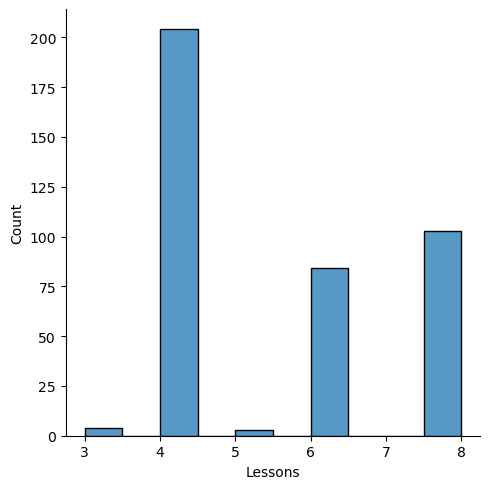

Q1


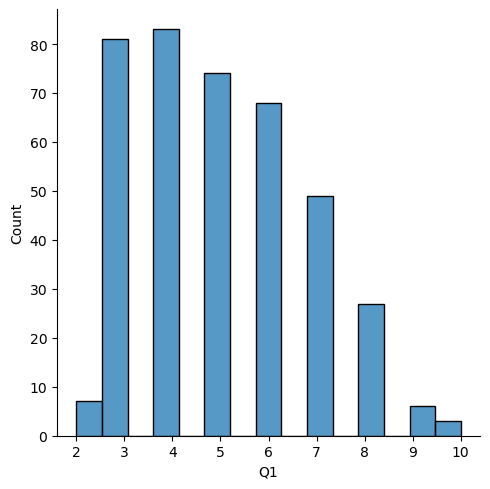

Q2


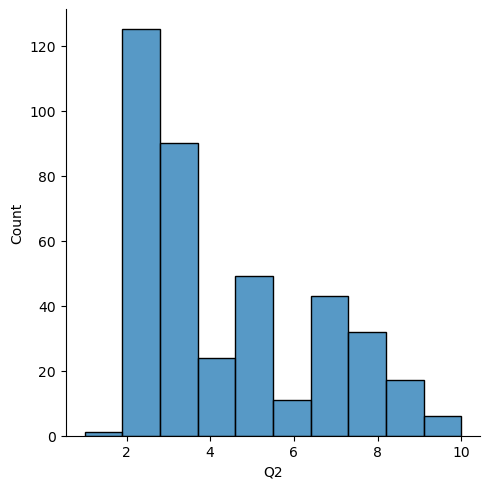

Q3


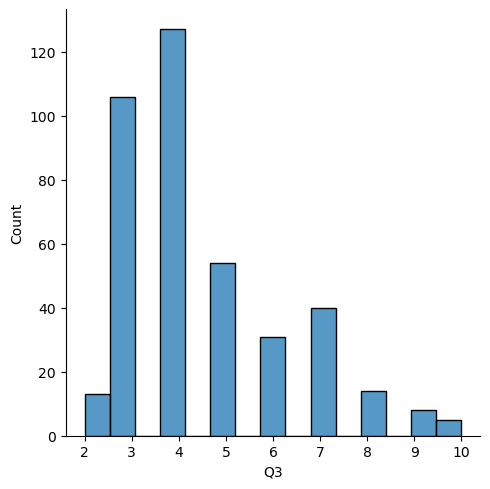

Q4


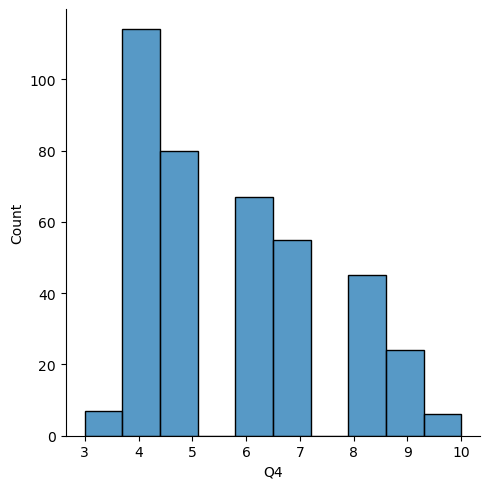

Q5


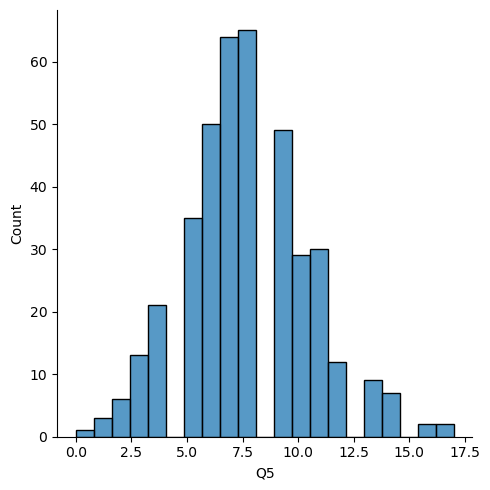

Q6


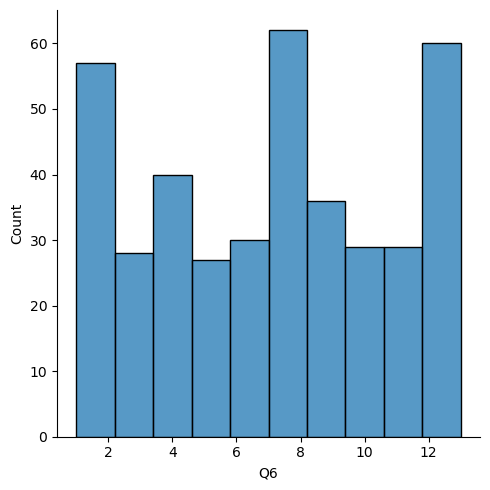

In [8]:
for col in data.columns:
    print(col)
    sns.displot(data[col])
    
    plt.show()

**Observations:**
- None of the variables seem to have any outliers, no need to drop any rows

#### Checking correlation

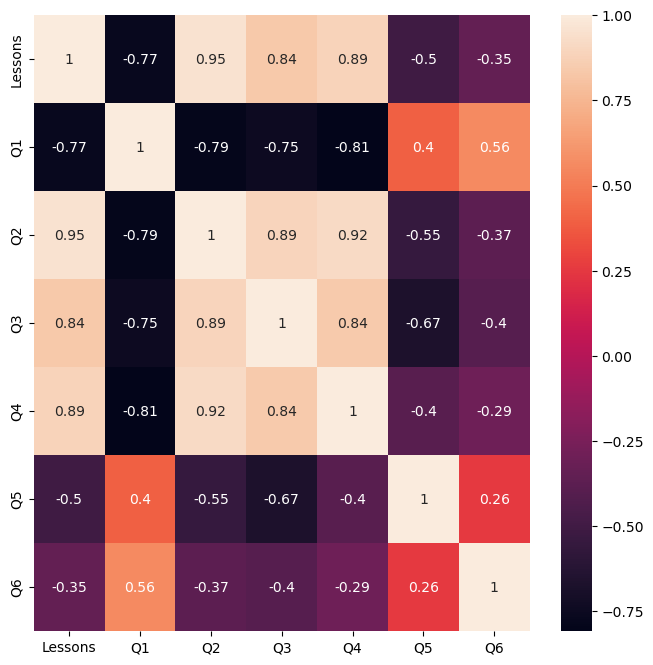

In [9]:
# Creating a new figure with a size of 8x8 inches
plt.figure(figsize=(8, 8))

# Creating a heatmap of the correlation matrix of the 'data' DataFrame
sns.heatmap(data.corr(), annot=True)

# Displaying the heatmap
plt.show()

**Observations:**
- Number of lifeskills lessons attended is highly related to Q2, Q3 and Q4 but negatively related to Q1, Q5 and Q6.
- Q2 and Q3 are highly positively related, same is Q2 and Q4.
- Q5 is negatively related to Q2, Q3 and Q4.

#### Scaling the data

In [10]:
# Transforming the 'data' DataFrame using the scaler and storing the scaled data in a new DataFrame called 'data_scaled'

data_scaled = pd.DataFrame(StandardScaler().fit_transform(data), columns=data.columns)

In [11]:
data_scaled.head()

,Lessons,Q1,Q2,Q3,Q4,Q5,Q6
0,-0.856321,-0.029601,-0.963124,0.24650,-1.057348,1.194492,-1.356642
1,0.320935,-0.029601,-0.113183,0.24650,0.131422,0.469232,-0.544290
2,-0.856321,2.326646,-0.963124,0.24650,-1.057348,0.469232,1.080415
3,-0.856321,-0.029601,-0.538153,0.24650,0.131422,-0.618658,1.080415
4,-0.856321,1.148522,-0.963124,-0.33747,-0.462963,0.106602,1.351199


## Principal Component Analysis

In [12]:
#Since there are a total of 7 columns we can generate 7 principal components


# Creating an instance of the PCA class with 7 components and a random state of 1
pca = PCA(n_components=7, random_state=1)

# applying PCA transformation to the scaled data using pca.fit_transform(data_scaled), projects the scaled data onto a new set of orthogonal axes (principal components).
data_pca1 = pd.DataFrame(pca.fit_transform(data_scaled))

# Calculating the explained variance ratio of each principal component and storing the results in the 'exp_var' variable
# the calculation of exp_var is automatically linked to the PCA transformation performed on the data_scaled
exp_var = pca.explained_variance_ratio_

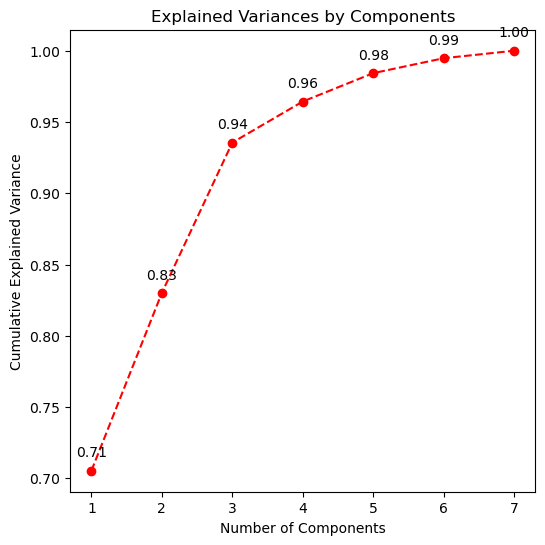

In [19]:
# visualize the explained variance by individual components

# Creating a new figure with a size of 10x10 inches
plt.figure(figsize=(6, 6))

# Plotting the cumulative explained variances as a line plot
plt.plot(range(1, 8), exp_var.cumsum(), marker='o', linestyle='--', color='red')


# Adding text annotations for each point
for i, var in enumerate(exp_var.cumsum()):
    plt.annotate(f'{var:.2f}', (i+1, var), textcoords="offset points", xytext=(0,10), ha='center')

# Setting the title of the plot
plt.title("Explained Variances by Components")

# Setting the label for the x-axis
plt.xlabel("Number of Components")

# Setting the label for the y-axis
plt.ylabel("Cumulative Explained Variance")

plt.show()

In [14]:
# find the least number of components that can explain more than 90% variance
sum = 0
for index, variance in enumerate(exp_var):
  sum += variance
  if(sum>0.90):
    print("Number of PCs that explain at least 90% variance: ", index+1)
    break

Number of PCs that explain at least 90% variance:  3


**Observations**:
-  We can see that out of the 7 original features, we reduced the number of features through principal components to 3, these components explain more than 90% of the original variance.
- So that is about 57% reduction in the dimensionality with a loss of 10% in variance.
- Let us now look at these principal components as a linear combination of original features.

In [15]:
# reflecting the original variables on the principal components

data_pca = pd.DataFrame(pca.components_[[0,1,2],:],index=['PC1','PC2','PC3'],columns=data.columns).T
data_pca

,PC1,PC2,PC3
Lessons,0.420635,-0.153049,0.164063
Q1,-0.395029,-0.250042,-0.222393
Q2,0.433670,-0.146844,0.108746
Q3,0.421986,-0.116167,-0.143724
Q4,0.412119,-0.172765,0.333788
Q5,-0.282479,0.192825,0.869022
Q6,-0.226365,-0.901093,0.156618


In [16]:
# Applying a color scheme so that the significant values can stand out

def color_high(val):
    if val <= -0.40: # you can decide any value as per your understanding
        return 'background: pink'
    elif val >= 0.40:
        return 'background: skyblue'   
    
data_pca.style.applymap(color_high)

,PC1,PC2,PC3
Lessons,0.420635,-0.153049,0.164063
Q1,-0.395029,-0.250042,-0.222393
Q2,0.433670,-0.146844,0.108746
Q3,0.421986,-0.116167,-0.143724
Q4,0.412119,-0.172765,0.333788
Q5,-0.282479,0.192825,0.869022
Q6,-0.226365,-0.901093,0.156618


**Observations:**

- Each principal component is a linear combination of original features. For example, we can write the equation for PC1 in the following manner:

0.42 * Lessons - 0.39 * Q1 + 0.43 * Q2 + 0.42 * Q3 + 0.41 * Q4 - 0.28 * Q5 - 0.23 * Q6

- Apart from Variable Lessons, the first principal component, PC1, is a measure of Q2 (I feel confident that I have what it takes to study, work or to do business successfully), Q3 (I can express to others the things that are important to me) and Q4(I am able to make my own decisions). A deeper scruitiny of the questions related to PC1 shows they talk about Confidence. We could call this Confidence dimension.

- PC2 has Q6 (I feel energetic to purse my goals) related to it. Q6 talks about motivation. We can call this Motivation dimension.

- PC3 has Q5 (The number of organisations that I know that can support me find a job, start a business or pursue further education) is related to knowledge and we can call it Knowledge dimension.

- It can be concluded that attending the lifeskills sessions mostly improved the confidence of the youth. The sessions also improved the motivation and knowledge of youth to a small extent.

#### We can also visualize the first two principal components with the most variance

Let's try adding hue to the scatter plot and project the attendance of lesson as it was the variable with the highest coefficient

Text(0, 0.5, 'Motivation component')

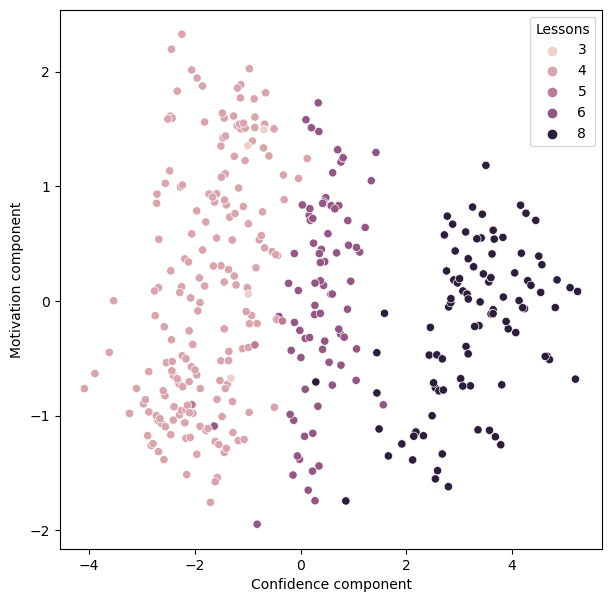

In [18]:
# Concatenating data_pca1 and data along the columns
df_concat = pd.concat([data_pca1, data], axis=1)

# Creating a new figure with a size of 7x7 inches
plt.figure(figsize=(7, 7))

# Creating a scatter plot with x-axis from column 0, y-axis from column 1, and colored by 'Lessons'
sns.scatterplot(x=0, y=1, data=df_concat, hue='Lessons')

# Setting the x-axis label to "PC1"
plt.xlabel("Confidence component")

# Setting the y-axis label to "PC2"
plt.ylabel("Motivation component")

**Observations and conclusion:**
The component that describes 71% of the data is highly related to confidence of the youth enrolled in the lifeskills project. The other component that explains another 12% of the data is motivation of the youth enrolled in the lifeskills project. In conclusion, motivation and confidence of the youth were the two components that mostly influenced youths ability to get a job. 

Additionally, we observe that with increase in confidence component 3 groups of beneficiaries emerge:

    - One with beneficiaries who have attended 3, 4, or 5 lessons
    - One with beneficiaries who have attended 6 lessons
    - One with beneficiaries who have attended 8 lessons
- However, the distinction between the groups is not strong and there are some overlaps.